MATRIZ DE LATÊNCIAS FÍSICAS D (0 = sem ligação):
 [[ 0.  4.  8.  0.  0.  0.  0.  0.  0. 12.]
 [ 4.  0.  3.  7.  0.  0.  0.  0.  0.  0.]
 [ 8.  3.  0.  2.  6.  0.  0.  0.  0.  0.]
 [ 0.  7.  2.  0.  5.  9.  0.  0.  0.  0.]
 [ 0.  0.  6.  5.  0.  4.  8.  0.  0.  0.]
 [ 0.  0.  0.  9.  4.  0.  3.  7.  0.  0.]
 [ 0.  0.  0.  0.  8.  3.  0.  2.  6.  0.]
 [ 0.  0.  0.  0.  0.  7.  2.  0.  5.  8.]
 [ 0.  0.  0.  0.  0.  0.  6.  5.  0.  3.]
 [12.  0.  0.  0.  0.  0.  0.  8.  3.  0.]]

ARESTAS DA TOPOLOGIA ACO (switches numerados 0 a 9): [(1, 2), (8, 9), (4, 5), (2, 3), (5, 6), (6, 7), (0, 1), (7, 8), (3, 4)]

MATRIZ DE ADJACÊNCIA FINAL (10 x 10):
 [[0 1 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0]
 [0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 1 0]]

Latência total da topologia aleatória: 59.00 ms
Latência total da topologia ACO: 31.00 ms
Ganho percentual: 47.46%
Árvor

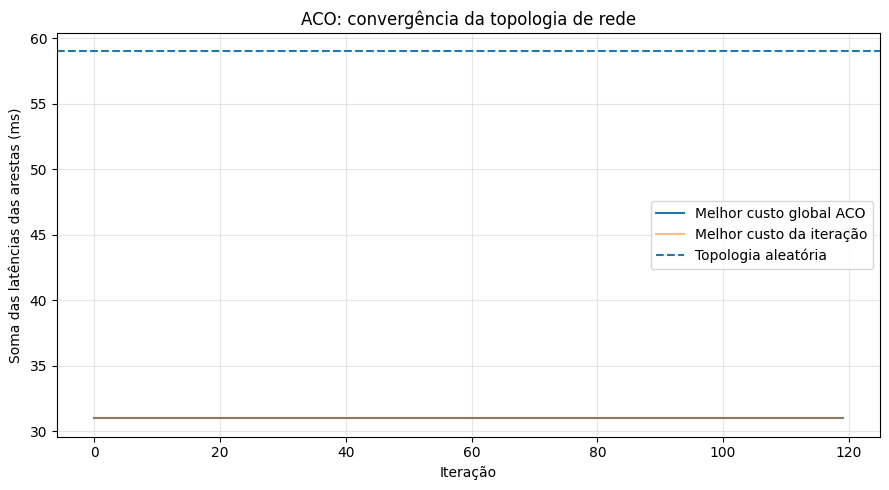

In [1]:

import numpy as np
import matplotlib.pyplot as plt

D = np.array([
[0, 4, 8, 0, 0, 0, 0, 0, 0, 12],
[4, 0, 3, 7, 0, 0, 0, 0, 0, 0],
[8, 3, 0, 2, 6, 0, 0, 0, 0, 0],
[0, 7, 2, 0, 5, 9, 0, 0, 0, 0],
[0, 0, 6, 5, 0, 4, 8, 0, 0, 0],
[0, 0, 0, 9, 4, 0, 3, 7, 0, 0],
[0, 0, 0, 0, 8, 3, 0, 2, 6, 0],
[0, 0, 0, 0, 0, 7, 2, 0, 5, 8],
[0, 0, 0, 0, 0, 0, 6, 5, 0, 3],
[12, 0, 0, 0, 0, 0, 0, 8, 3, 0]
], dtype=float)
N = len(D)
assert D.shape == (10, 10) and np.allclose(D, D.T) and np.allclose(np.diag(D), 0)
EDGES = [(i, j) for i in range(N) for j in range(i+1, N) if D[i,j] > 0]

class UnionFind:
    def __init__(self, n): self.parent=list(range(n)); self.rank=[0]*n; self.components=n
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        a,b=self.find(a),self.find(b)
        if a==b: return False
        if self.rank[a]<self.rank[b]: a,b=b,a
        self.parent[b]=a
        if self.rank[a]==self.rank[b]: self.rank[a]+=1
        self.components-=1
        return True

def validar_arvore(edges):
    if len(edges)!=N-1: return False
    uf=UnionFind(N)
    return all(uf.union(i,j) for i,j in edges) and uf.components==1

def custo(edges): return float(sum(D[i,j] for i,j in edges))

def construir_arvore(tau, rng, alpha=1.0, beta=2.0):
    uf=UnionFind(N); arvore=[]
    while len(arvore)<N-1:
        candidatos=[(i,j) for i,j in EDGES if uf.find(i)!=uf.find(j)]
        if not candidatos: raise ValueError('Grafo físico desconectado: impossível formar árvore.')
        pesos=np.array([(tau[i,j]**alpha)*(1.0/D[i,j])**beta for i,j in candidatos])
        pesos=pesos/pesos.sum()
        i,j=candidatos[int(rng.choice(len(candidatos),p=pesos))]
        uf.union(i,j); arvore.append((i,j))
    assert validar_arvore(arvore)
    return arvore

def arvore_aleatoria(rng):
    uf=UnionFind(N); arvore=[]
    for k in rng.permutation(len(EDGES)):
        i,j=EDGES[k]
        if uf.union(i,j): arvore.append((i,j))
        if len(arvore)==N-1: break
    if not validar_arvore(arvore): raise ValueError('Grafo desconectado.')
    return arvore

def aco(n_formigas=35, iteracoes=120, rho=0.2, alpha=1.0, beta=2.0, elite=5, seed=42):
    rng=np.random.default_rng(seed)
    tau=np.where(D>0,1.0,0.0)
    melhor=None; melhor_custo=float('inf'); historico=[]; historico_iter=[]
    for _ in range(iteracoes):
        solucoes=sorted([(custo(a),a) for a in [construir_arvore(tau,rng,alpha,beta) for _ in range(n_formigas)]],key=lambda x:x[0])
        if solucoes[0][0]<melhor_custo:
            melhor_custo,melhor=solucoes[0][0],list(solucoes[0][1])
        tau *= 1-rho  # evaporação global; depósito APENAS nas melhores da iteração
        for c,arvore in solucoes[:elite]:
            for i,j in arvore:
                tau[i,j]+=1.0/c; tau[j,i]+=1.0/c
        tau=np.maximum(tau, np.where(D>0,1e-8,0))
        historico.append(melhor_custo); historico_iter.append(solucoes[0][0])
    return melhor,melhor_custo,np.array(historico),np.array(historico_iter),tau


rng_base=np.random.default_rng(2026)
baseline=arvore_aleatoria(rng_base)
solucao,latencia_aco,historico,historico_iter,tau=aco(rho=0.2)
latencia_base=custo(baseline)
ganho=100*(latencia_base-latencia_aco)/latencia_base
adj=np.zeros((N,N),dtype=int)
for i,j in solucao: adj[i,j]=adj[j,i]=1
assert validar_arvore(solucao) and adj.sum()==2*(N-1)
print('MATRIZ DE LATÊNCIAS FÍSICAS D (0 = sem ligação):\n',D)
print('\nARESTAS DA TOPOLOGIA ACO (switches numerados 0 a 9):',solucao)
print('\nMATRIZ DE ADJACÊNCIA FINAL (10 x 10):\n',adj)
print(f'\nLatência total da topologia aleatória: {latencia_base:.2f} ms')
print(f'Latência total da topologia ACO: {latencia_aco:.2f} ms')
print(f'Ganho percentual: {ganho:.2f}%')
print('Árvore válida:',validar_arvore(solucao),'| 9 arestas:',len(solucao)==9)
plt.figure(figsize=(9,5))
plt.plot(historico,label='Melhor custo global ACO')
plt.plot(historico_iter,label='Melhor custo da iteração',alpha=0.5)
plt.axhline(latencia_base,linestyle='--',label='Topologia aleatória')
plt.xlabel('Iteração');plt.ylabel('Soma das latências das arestas (ms)')
plt.title('ACO: convergência da topologia de rede');plt.legend();plt.grid(alpha=.3)
plt.tight_layout();plt.savefig('lab03_convergencia.png',dpi=180);plt.show()
np.savetxt('lab03_matriz_adjacencia.csv',adj,delimiter=',',fmt='%d')
